# ![Machine Learning Lab](banner.jpg)

# Laboratorio 11 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Descarga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab11.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Aplicar técnicas de procesamiento de lenguaje natural con modelos BERT para resolver una tarea de clasificación de texto multiclase.
2. Comparar el desempeño entre un modelo entrenado desde cero y uno con fine-tuning de un modelo preentrenado.
3. Evaluar modelos con métricas de clasificación.

---

En esta ocasión trabajaremos con el dataset **BBC Full Text Document Classification**, que contiene artículos de noticias de la BBC clasificados en 5 categorías: **business**, **entertainment**, **politics**, **sport** y **tech**.

Dataset: [BBC Full Text Document Classification](https://www.kaggle.com/datasets/alfathterry/bbc-full-text-document-classification)

---

## Instrucciones

### 1. Carga y preparación de datos (10%)

1. Descargue el dataset. La columna `data` contiene los artículos y `labels` es la variable objetivo.
2. Limpie el dataset aplicando preprocesamiento básico de texto (minúsculas, eliminación de caracteres especiales).
3. Separe el dataset en entrenamiento y prueba usando 10% para testing.

---

### 2. Tokenización (10%)

1. Utilice el tokenizador de `bert-base-uncased` para tokenizar los datasets de entrenamiento y prueba.

---

### 3. Definición de arquitectura del modelo (10%)

1. Usando capas densas, agregue una cabeza de clasificación a un modelo BERT.
2. Muestre el resumen del modelo e indique el número total de parámetros.

---

### 4. Entrenamiento desde cero (30%)

1. Parta únicamente de la arquitectura (no use pesos pre-entrenados).
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 5. Fine-Tuning con modelo preentrenado (30%)

1. Parta de un modelo BERT pre-entrenado.
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 6. Comparación de resultados (10%)

1. Compare el accuracy de ambos modelos en el conjunto de prueba y explique los resultados obtenidos.

---


# 1. Carga y preparación de datos


In [147]:
# librearías a usar
# cargar los datos
import kagglehub

# procesamiento del texto y etiquetas
import re
from sklearn.preprocessing import LabelEncoder

# lectura de archivos
import os
import sys
import pandas as pd

# gráficas
import seaborn as sns
import matplotlib.pyplot as plt

# tokenizers y modelos
from transformers import AutoTokenizer, AutoModel
from transformers import BertConfig, BertModel

# separación en conjuntos y métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# tiempos de ejecución
import time

# modelos
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ignorar warnings
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [117]:
# descargar el dataset de Kaggle
path = kagglehub.dataset_download("alfathterry/bbc-full-text-document-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbc-full-text-document-classification' dataset.
Path to dataset files: /kaggle/input/bbc-full-text-document-classification


In [118]:
# explorar los archivos descargados
print(f"Archivos en el directorio descargado: {os.listdir(path)}")

Archivos en el directorio descargado: ['bbc_data.csv']


In [119]:
# cargar el dataset
bbc_data = pd.read_csv(os.path.join(path, "bbc_data.csv"))

# mostrar las primeras filas del dataset
bbc_data.head()

,data,labels
0,Musicians to tackle US red tape Musicians gro...,entertainment
1,"U2s desire to be number one U2, who have won ...",entertainment
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment
3,Snicket tops US box office chart The film ada...,entertainment
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment


Vamos a explorar la distribución de las categorías en el dataset.

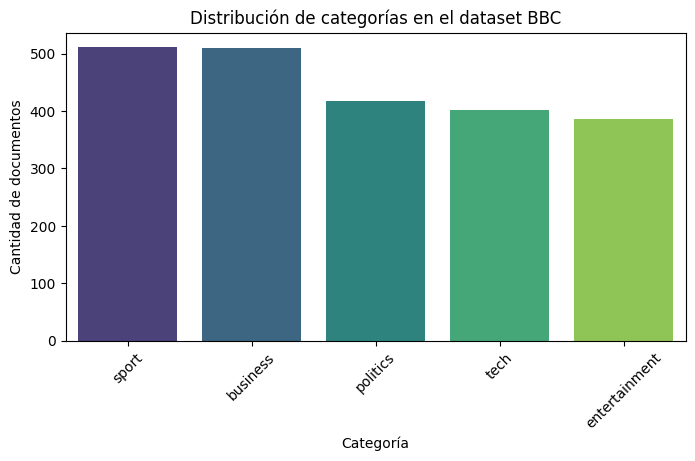

In [120]:
# grafico de barras para mostrar la distribución de categorías
plt.figure(figsize=(8, 4))
sns.countplot(data=bbc_data, x='labels', order=bbc_data['labels'].value_counts().index, palette='viridis')
plt.title('Distribución de categorías en el dataset BBC')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de documentos')
plt.xticks(rotation=45)
plt.show()

A continuación, se limpia el dataset aplicando paso a minúsculas y eliminación de caracteres especiales. Luego, se separa el dataset en entrenamiento y prueba usando un 10% para testing.

In [121]:
# definir función de limpieza de texto
def clean_text(text):
    # convertir a minúsculas
    text = text.lower()
    # eliminar caracteres especiales
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # eliminar espacios extra
    text = re.sub(r'\s+', ' ', text).strip()
    return text

bbc_data['cleaned_text'] = bbc_data['data'].apply(clean_text)
# mostrar las primeras filas del dataset con el texto limpio
bbc_data[['data', 'cleaned_text']].head()

,data,cleaned_text
0,Musicians to tackle US red tape Musicians gro...,musicians to tackle us red tape musicians grou...
1,"U2s desire to be number one U2, who have won ...",u2s desire to be number one u2 who have won th...
2,Rocker Doherty in on-stage fight Rock singer ...,rocker doherty in onstage fight rock singer pe...
3,Snicket tops US box office chart The film ada...,snicket tops us box office chart the film adap...
4,"Oceans Twelve raids box office Oceans Twelve,...",oceans twelve raids box office oceans twelve t...


In [122]:
# separar el dataset en entrenamiento y prueba
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(bbc_data['cleaned_text'], bbc_data['labels'], test_size=0.1, random_state=RANDOM_STATE)

# tamaño de los conjuntos de entrenamiento y prueba
print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")

Tamaño del conjunto de entrenamiento: 2002
Tamaño del conjunto de prueba: 223


# 2. Tokenización

In [123]:
# se carga el tokenizador de BERT
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

In [124]:
# tokenizar los textos de entrenamiento y prueba
tokenized_train = tokenizer(list(X_train), truncation=True, padding=True, max_length=512, return_tensors='pt')
tokenized_test = tokenizer(list(X_test), truncation=True, padding=True, max_length=512, return_tensors='pt')

In [125]:
# vemos un ejemplo de texto tokenizado
print("Ejemplo de texto original:")
print(X_train.iloc[0][:100])
print("\nEjemplo de texto tokenizado:")
print(tokenized_train['input_ids'][0][:20])

Ejemplo de texto original:
call to overhaul uk state pension the uk pension system has been branded inadequate and too complex 

Ejemplo de texto tokenizado:
tensor([  101,  2655,  2000, 18181,  2866,  2110, 11550,  1996,  2866, 11550,
         2291,  2038,  2042, 11180, 14710,  1998,  2205,  3375,  2011,  1037])


A continuación se define el Dataset y DataLoader para el uso de pytorch.

In [126]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # retorna un diccionario con los tensores de input_ids, attention_mask y labels para el índice dado
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long) # CrossEntropyLoss espera etiquetas como enteros largos
        return item

    def __len__(self):
        return len(self.labels)

In [127]:
# pasar las etiquetas a valores con label encoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# crear datasets
train_dataset = NewsDataset(tokenized_train, y_train)
test_dataset = NewsDataset(tokenized_test, y_test)

In [128]:
# crear dataloaders con un batch size definido
BATCH_SIZE = 12
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Arquitectura del modelo

A continuación se crea el modelo, el cual cuenta con dos opciones:
1. Carga del modelo BERT con pesos pre-entrenados.
2. Carga de la arquitectura BERT sin los pesos pre-entrenados.

In [129]:
class BertClassifier(nn.Module):
    def __init__(self, num_labels=5, pretrained=True):
        super().__init__()

        if pretrained: # si el modelo es preentrenado, se carga con los pesos de BERT base uncased
            self.bert = AutoModel.from_pretrained("bert-base-uncased")
        else: # si no es preentrenado, se carga la arquitectura de BERT sin los pesos
            self.bert = BertModel(BertConfig())

        hidden_size = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # obtener embeddings de BERT
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        # embedding del token [CLS] para clasificación
        cls_output = outputs.last_hidden_state[:, 0, :]

        # logits de clasificación (sin softmax, se aplicará CrossEntropyLoss que incluye softmax)
        logits = self.classifier(cls_output)

        return logits


### Arquitectura y parámetros del modelo

Se muestra la arquitectura y el número total de parámetros de parámetros entrenables. Es importante notar que tanto para el modelo cargado sin pesos pre-entrenados como para el modelo con pesos pre-entrenados, el número de parámetros entrenables corresponde al total de pesos, incluyendo los de BERT, ya que no se congelan los pesos de BERT en ninguno de los dos casos.

La diferencia entre ambos radica en que el modelo con pesos pre-entrenados ya tiene pesos inicializados que han sido entrenados en una extensa cantidad de texto, mientras que el modelo sin pesos pre-entrenados se inicializa con pesos aleatorios.

In [130]:
# imprimir la arquitectura del modelo
bert_classifier = BertClassifier(num_labels=5, pretrained=False)
bert_classifier

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [131]:
# contar el número de parámetros entrenables y número de parámetros totales (debe ser el mismo)
total_params = sum(p.numel() for p in bert_classifier.parameters())
trainable_params = sum(p.numel() for p in bert_classifier.parameters() if p.requires_grad)
print(f"Número de parámetros totales: {total_params}")
print(f"Número de parámetros entrenables: {trainable_params}")

Número de parámetros totales: 109680389
Número de parámetros entrenables: 109680389


# 4. Entrenamiento desde cero

Definimos Cross Entropy Loss como función de pérdida al ser un problema de clasificación multiclase, y AdamW como optimizador. Para el entrenamiento desde cero, se usa una taza de aprendizaje de 0.001, ya que el modelo no tiene necesita aprender desde cero, explorando el espacio de búsqueda.

Para este modelo se utilizarán además 20 épocas.

In [132]:
# instanciar el modelo
model_only_architecture = BertClassifier(num_labels=5, pretrained=False).to(device)

# función de pérdida
criterion = torch.nn.CrossEntropyLoss()

# optimizador
optimizer = torch.optim.AdamW(model_only_architecture.parameters(), lr=0.001)

In [133]:
# función de entrenamiento del modelo - por epoch
def train_epoch(model, dataloader, optimizer, criterion, device):
    # poner el modelo en modo entrenamiento para habilitar el cálculo de gradientes
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in dataloader:
        # obtener los tensores de input_ids, attention_mask y labels del batch y enviarlos al dispositivo
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # limpiar los gradientes acumulados del optimizador antes de backprop
        optimizer.zero_grad()

        # feedforward para obtener las salidas del modelo
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # backpropagation y actualización de pesos
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # acumular la pérdida total para calcular el promedio al final
        total_loss += loss.item()

        # calcular el número de predicciones correctas para calcular la precisión al final
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # calcular la pérdida promedio y la precisión para el epoch
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [134]:
# función de evaluación del modelo - por epoch
def eval_model(model, dataloader, criterion, device):
    # poner el modelo en modo evaluación
    model.eval()

    # guardar la pérdida total, número de predicciones correctas y total de muestras
    total_loss = 0
    correct = 0
    total = 0

    # desactivar el cálculo de gradientes para evaluación
    with torch.no_grad():
        for batch in dataloader:
            # se obtienen los tensores de input_ids, attention_mask y labels del batch y se envían al dispositivo
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # obtener las salidas del modelo
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # calcular la pérdida para el batch actual
            loss = criterion(outputs, labels)

            # acumular la pérdida total para calcular el promedio al final
            total_loss += loss.item()

            # obtener las predicciones del modelo y comparar con las etiquetas para calcular la precisión
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # calcular la pérdida promedio y la precisión
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [145]:
def evaluate_test(model, testloader, device, label_encoder):
    # poner el modelo en modo evaluación
    model.eval()

    # guardar etiquetas predichas y verdaderas
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in testloader:
            # extraer las etiquetas
            labels = batch.pop("labels").to(device)

            # pasar los tensores a device
            inputs = {k: v.to(device) for k, v in batch.items()}

            # pasar los argumentos al modelo desempaquetando inputs
            logits = model(**inputs)

            # obtener la clase con mayor prob
            _, predicted = torch.max(logits, 1)

            # guardar los resultados
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # calcular el accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # obtener el reporte de clasificación y la matriz de confusión
    target_names = label_encoder.classes_
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)

    plt.title('Matriz de Confusión')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    return y_true, y_pred, accuracy

In [136]:
# entrenamiento del modelo
EPOCHS = 20

# guardar las pérdidas y precisiones de entrenamiento y validación para cada época
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time_total = time.time()

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")

    start_time_epoch = time.time()

    # entrenar y evaluar el modelo
    train_loss, train_acc = train_epoch(model_only_architecture, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model_only_architecture, test_loader, criterion, device)

    end_time_epoch = time.time()
    epoch_duration = end_time_epoch - start_time_epoch

    # guardar resultados
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Tiempo de la época: {epoch_duration:.2f}s")

end_time_total = time.time()
total_duration = end_time_total - start_time_total
print(f"Tiempo total de entrenamiento: {total_duration/60:.2f} minutos")


Epoch 1/20
Train Loss: 1.6557 | Train Acc: 0.2163
Val Loss:   1.6158 | Val Acc:   0.1614
Tiempo de la época: 213.22s

Epoch 2/20
Train Loss: 1.6099 | Train Acc: 0.2268
Val Loss:   1.6060 | Val Acc:   0.2511
Tiempo de la época: 209.16s

Epoch 3/20
Train Loss: 1.6073 | Train Acc: 0.2203
Val Loss:   1.6021 | Val Acc:   0.2511
Tiempo de la época: 208.46s

Epoch 4/20
Train Loss: 1.6063 | Train Acc: 0.2163
Val Loss:   1.6106 | Val Acc:   0.2197
Tiempo de la época: 206.56s

Epoch 5/20
Train Loss: 1.6058 | Train Acc: 0.2308
Val Loss:   1.6084 | Val Acc:   0.2197
Tiempo de la época: 195.13s

Epoch 6/20
Train Loss: 1.6042 | Train Acc: 0.2278
Val Loss:   1.6072 | Val Acc:   0.2197
Tiempo de la época: 195.21s

Epoch 7/20
Train Loss: 1.6033 | Train Acc: 0.2308
Val Loss:   1.6064 | Val Acc:   0.2197
Tiempo de la época: 194.87s

Epoch 8/20
Train Loss: 1.6029 | Train Acc: 0.2308
Val Loss:   1.6059 | Val Acc:   0.2197
Tiempo de la época: 195.09s

Epoch 9/20
Train Loss: 1.6026 | Train Acc: 0.2308
Val L

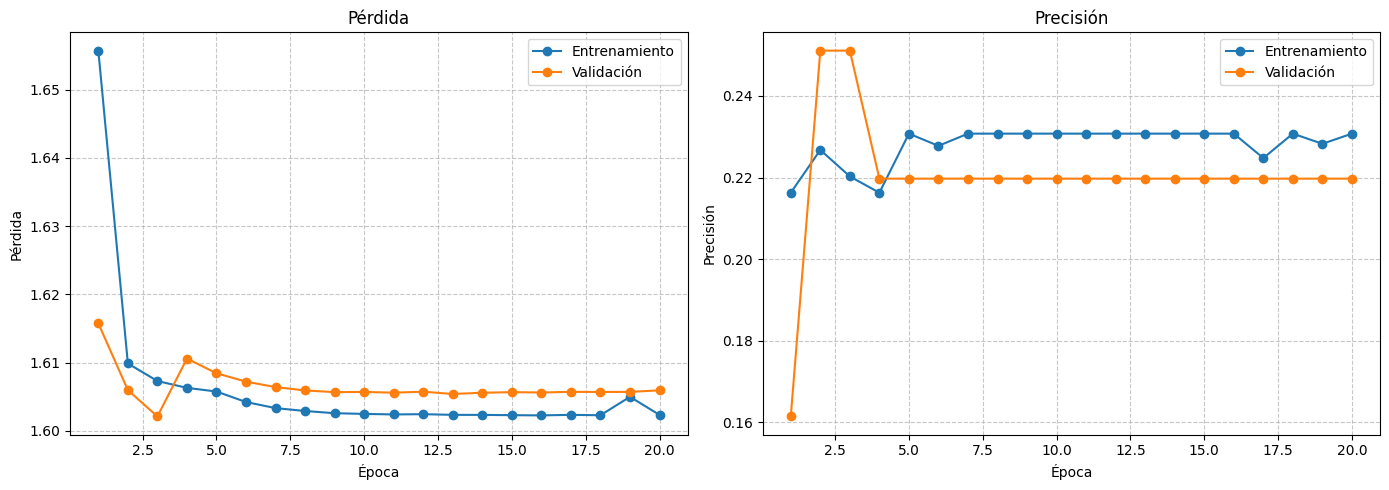

In [137]:
# graficar las curvas de aprendizaje
plt.figure(figsize=(14, 5))

# pérdida
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Entrenamiento', marker='o', color='#1f77b4')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validación', marker='o', color='#ff7f0e')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Entrenamiento', marker='o', color='#1f77b4')
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Validación', marker='o', color='#ff7f0e')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

En las curvas de aprendizaje se observa una convergencia prematura cercana a la época 5. No se evidencian señales de overfitting.

### Evaluación del modelo

               precision    recall  f1-score   support

     business       0.00      0.00      0.00        56
entertainment       0.00      0.00      0.00        45
     politics       0.00      0.00      0.00        36
        sport       0.22      1.00      0.36        49
         tech       0.00      0.00      0.00        37

     accuracy                           0.22       223
    macro avg       0.04      0.20      0.07       223
 weighted avg       0.05      0.22      0.08       223



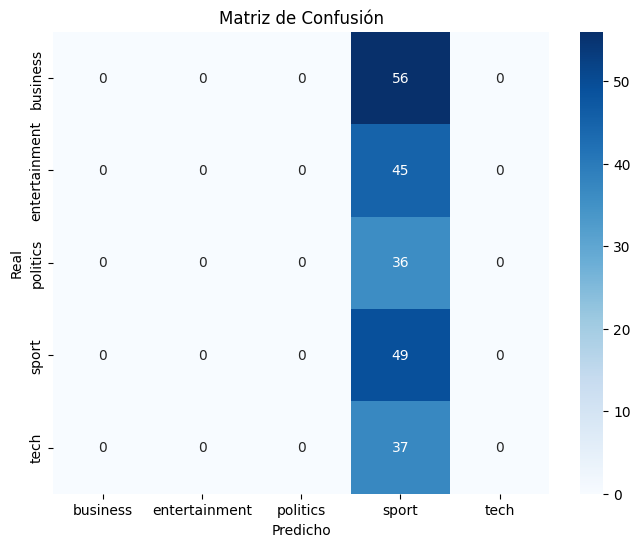

In [148]:
# obtener matriz de confusión y reporte de clasificación
_, _, accuracy_only_architecture = evaluate_test(model_only_architecture, test_loader, device, label_encoder)

# 5. Entrenamiento con modelo pre-entrenado

Instanciamos el modelo y usamos un learning rate mucho menor al del modelo entrenado desde cero. Esto se debe a que no queremos caer en olvido catastrófico.

In [139]:
# borar el cache de la gpu para que no haya problemas en entrenamiento
torch.cuda.empty_cache()

In [140]:
# instanciar el modelo
model_pretrained = BertClassifier(num_labels=5, pretrained=True).to(device)

# función de pérdida
criterion = torch.nn.CrossEntropyLoss()

# optimizador
optimizer = torch.optim.AdamW(model_pretrained.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nota: los parámetros que no está encontrando al cargar el modelo se debe a que únicamente carga el cuerpo del transformer, sin las cabezas para las tareas en las que fue entrenado. Esto es correcto debido a que se está usando con una nueva cabeza para clasificación.

A continuación se entrena el modelo.

In [141]:
# entrenamiento del modelo
EPOCHS = 5

# guardar las pérdidas y precisiones de entrenamiento y validación para cada época
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time_total = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    start_time_epoch = time.time()

    # entrenar y evaluar el modelo
    train_loss, train_acc = train_epoch(model_pretrained, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model_pretrained, test_loader, criterion, device)

    end_time_epoch = time.time()
    epoch_duration = end_time_epoch - start_time_epoch

    # guardar resultados
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Tiempo de la época: {epoch_duration:.2f}s")

end_time_total = time.time()
total_duration = end_time_total - start_time_total
print(f"\nTiempo total de entrenamiento: {total_duration/60:.2f} minutos")


Epoch 1/5
Train Loss: 0.4983 | Train Acc: 0.8966
Val Loss:   0.1133 | Val Acc:   0.9821
Tiempo de la época: 214.79s

Epoch 2/5
Train Loss: 0.0791 | Train Acc: 0.9870
Val Loss:   0.0981 | Val Acc:   0.9776
Tiempo de la época: 214.88s

Epoch 3/5
Train Loss: 0.0393 | Train Acc: 0.9945
Val Loss:   0.0834 | Val Acc:   0.9821
Tiempo de la época: 214.34s

Epoch 4/5
Train Loss: 0.0173 | Train Acc: 0.9980
Val Loss:   0.1166 | Val Acc:   0.9776
Tiempo de la época: 214.53s

Epoch 5/5
Train Loss: 0.0219 | Train Acc: 0.9955
Val Loss:   0.0766 | Val Acc:   0.9821
Tiempo de la época: 214.65s

Tiempo total de entrenamiento: 17.89 minutos


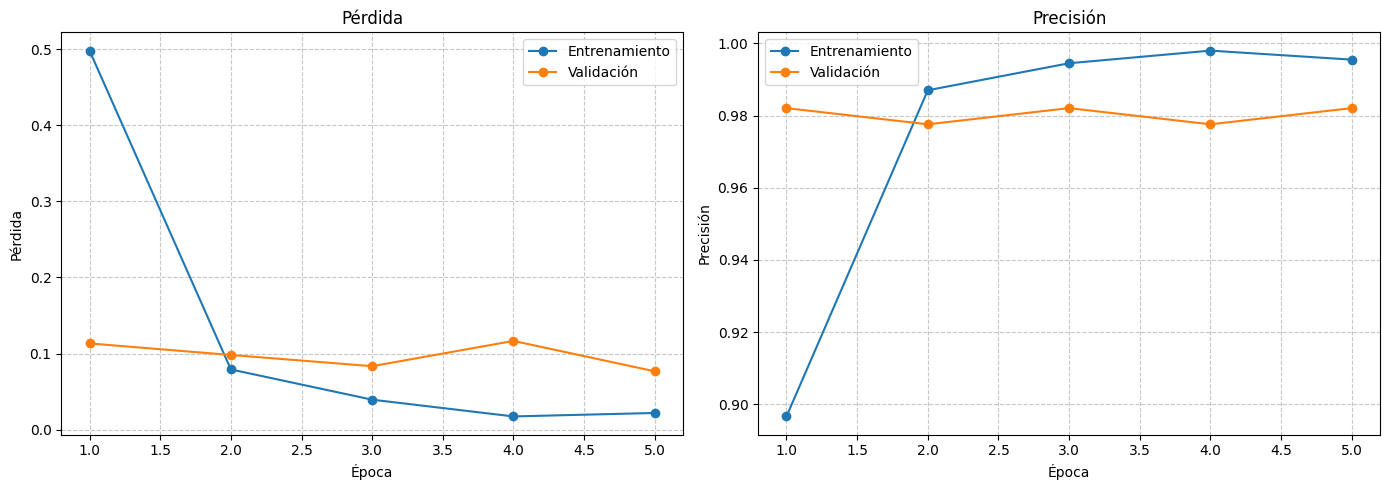

In [143]:
# graficar las curvas de aprendizaje
plt.figure(figsize=(14, 5))

# pérdida
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Entrenamiento', marker='o', color='#1f77b4')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validación', marker='o', color='#ff7f0e')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Entrenamiento', marker='o', color='#1f77b4')
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Validación', marker='o', color='#ff7f0e')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Las curvas de aprendizaje evidencian una convergencia correcta del modelo. No se observa overfitting.

### Evaluación del modelo

               precision    recall  f1-score   support

     business       0.98      0.96      0.97        56
entertainment       1.00      0.98      0.99        45
     politics       0.95      1.00      0.97        36
        sport       1.00      0.98      0.99        49
         tech       0.97      1.00      0.99        37

     accuracy                           0.98       223
    macro avg       0.98      0.98      0.98       223
 weighted avg       0.98      0.98      0.98       223



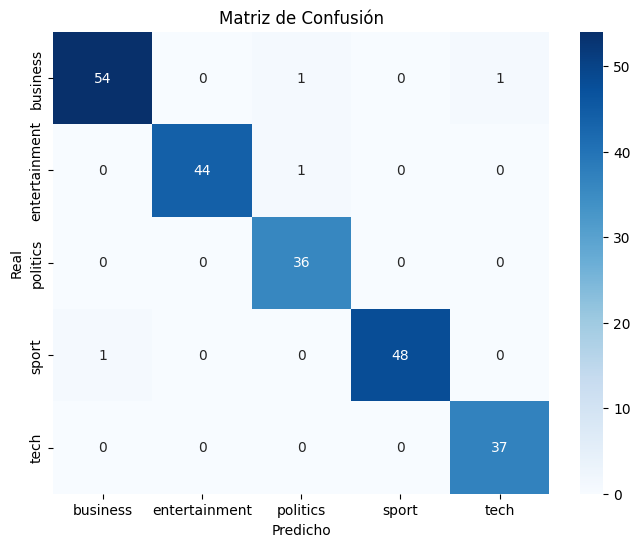

In [149]:
# obtener matriz de confusión y reporte de clasificación
_, _, accuracy_pretrained = evaluate_test(model_pretrained, test_loader, device, label_encoder)

# 6. Comparación de resultados.

In [151]:
# obtener accuracy con ambos modelos
print(f"Accuracy modelo sin pesos pre-entrenados: {accuracy_only_architecture:.4f}")
print(f"Accuracy modelo con pesos pre-entrenados: {accuracy_pretrained:.4f}")

Accuracy modelo sin pesos pre-entrenados: 0.2197
Accuracy modelo con pesos pre-entrenados: 0.9821


Se observa una gran diferencia en el performance entre el modelo sin pesos pre-entrenados y la versión con ellos. El primer modelo no logra aprender satisfactoriamente las representaciones o embeddings del texto, lo que impide que la cabeza de clasificación distinga correctamente las categorías. Esto se debe, principalmente, a que una red tipo BERT requiere millones de ejemplos para aprender desde cero, mientras que aquí solo se cuenta con 2002 muestras de entrenamiento. Además, al entrenar únicamente durante 20 épocas, el modelo, según las curvas de aprendizaje, parece caer prematuramente en un mínimo local que no es el óptimo para el problema. Es además interesante notar que predice todos los ejemplos como la clase "sport", la cual es mayoritaria en el conjunto de datos. Este comportamiento puede ocurre porque, ante la incapacidad de extraer patrones semánticos de los embeddings aleatorios, el optimizador minimiza la pérdida asignando siempre la etiqueta más frecuente.

En cambio, el uso de pesos pre-entrenados ya captura el significado y contexto de las palabras, facilitando que el fine-tuning llegue a las representaciones correctas para la clasificación. En general, el entrenamiento completo de la red no es recomendable sin un corpus extenso y grandes recursos computacionales, siendo el fine-tuning la opción óptima cuando el número de muestras es reducido.